# Statistiques de visdrone

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrivals/EmbeddedComputervision/blob/main/notebooks/visdrone/visdrone_stats.ipynb)

Présentation et analyse statistique du jeu, lues du point de vue de Tiny-YOLO et de la
cible embarquée (entrée 416, grilles 13×13 et 26×26, 256 emplacements de `yolo_post`,
INT8). Tâches : [T11.5](../../docs/tasks/M11-jeux-de-donnees.md), [T16.15](../../docs/tasks/M16-presentation-jeux.md), [T16.4](../../docs/tasks/M16-presentation-jeux.md) ; jalon : [M16](../../docs/tasks/M16-presentation-jeux.md) ;
synthèse : [stats-jeux.md](../../docs/tasks/stats-jeux.md). Autres notebooks du jeu :
[tiny-yolov2-voc_infer](tiny-yolov2-voc_infer.ipynb), [tiny-yolov3-coco_infer](tiny-yolov3-coco_infer.ipynb), [tiny-yolov3-visdrone_infer](tiny-yolov3-visdrone_infer.ipynb), [tiny-yolov3-visdrone_train](tiny-yolov3-visdrone_train.ipynb), [tiny-yolov3-visdrone_sweep](tiny-yolov3-visdrone_sweep.ipynb).

Palier : annotations **M (en-têtes d'image lus)** (split entier), pixels **M** (`SAMPLE = 200`
images par partie). Prérequis : données `data/visdrone/VisDrone2019-DET-val/annotations` — tools/get_datasets.sh visdrone (inscription : source affichée). Ni poids ni GPU.

Question propre : Part des objets plus petits qu'une cellule 26×26 ; collisions de cibles. (renvoi : T11.5, T15).

| | |
|---|---|
| source | https://github.com/VisDrone/VisDrone-Dataset |
| version | VisDrone2019-DET (train, val, test-dev) |
| licence | recherche, non commerciale |
| capteur | caméras de drones, 14 villes de Chine, altitudes et angles variés |
| résolution typique | 960×540 à 2000×1500 |
| officiel `train` | 6471 images, — objets |
| officiel `val` | 548 images, — objets |
| chargeur | régions ignorées (catégorie 0) et « others » (11) retirées par le chargeur |

Aucun calcul ici : `tools/data_stats.py` calcule (`stats.json`, `stats.md`, galerie),
`tools/figures/donnees.py` trace ; chaque étape affiche la commande. Sorties dans
`build/notebooks/visdrone/stats/`, jamais dans `results/`. Notebook généré par `python -m tools.notebooks`
(`make notebooks`) : modifier `tools/notebooks/gabarits.py`, pas ce fichier.

## Paramètres

In [1]:
DATASET   = 'visdrone'  # clé de DATASETS
SPLITS    = None  # liste de splits ; None : splits train puis test du jeu
SIZE      = None  # S ou 'LxH' ; None : entrée de la cfg du jeu (416 sinon)
RESIZE    = 'letterbox'  # letterbox | stretch (grandeurs vues par le réseau)
SAMPLE    = 200  # images lues pour les pixels, par partie ; 0 : aucune
GALLERY   = 8  # images de la galerie par split
SEED      = 0  # tirage des images (pixels, galerie, nuages)
NET       = 'build/m11/cfg/tiny-yolov3-visdrone.cfg'  # cfg dont les ancres et grilles servent aux collisions
DEVICE    = 'cpu'  # noyau CPU : rien ne tourne sur GPU
DATA_ROOT = None  # racine du jeu ; None : data/<jeu> (Colab : dossier Drive)
DRIVE_DIR = '/content/drive/MyDrive/EmbeddedCV'  # Colab : archives data/<jeu>.tar ; None : pas de Drive
OUT       = 'build/notebooks/visdrone/stats'  # sorties du notebook
REPO_URL  = 'https://github.com/lrivals/EmbeddedComputervision.git'  # Colab : dépôt cloné
REV       = 'main'  # Colab : révision

## Environnement

Local : rien n'est installé ni téléchargé, la cellule vérifie les prérequis et
s'arrête avec la commande à lancer. Colab : clone du dépôt, installation, CuPy si
`DEVICE = "gpu"`, poids, puis données par `colab.prepare_data` (archive
`<DRIVE_DIR>/data/<jeu>.tar` ou téléchargement direct ; ExDark et FLIR : archive
seulement, faite sur le PC par `tools/get_datasets.sh pack <jeu>`).

In [2]:
import os
import subprocess
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules


def repo_root():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "tools" / "notebooks" / "commandes.py").exists():
            return d
    return None


ROOT = repo_root()
if COLAB:
    if ROOT is None:
        ROOT = Path("/content/EmbeddedComputervision")
        if not ROOT.exists():
            subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    # Clone d'une session précédente : remis à REV (notebook et code du même commit).
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin", REV], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "-q", "FETCH_HEAD"], check=True)
    for m in [m for m in sys.modules if m.split(".")[0] in ("tools", "yolo")]:
        del sys.modules[m]  # modules importés avant la mise à jour
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    f"{ROOT}/python[data,plots]"], check=True)
    if DEVICE == "gpu":
        # Runtime CPU : pas de pilote, CuPy dirait « cudaErrorInsufficientDriver ».
        try:
            smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        except FileNotFoundError:
            smi = None
        if smi is None or smi.returncode != 0:
            raise RuntimeError("runtime Colab sans GPU : créer un nouveau serveur Colab "
                               "de type GPU (T4, L4 ou A100), ou DEVICE = 'cpu'")
        cuda = smi.stdout.split("CUDA Version:")[-1].split()[0]  # version du pilote
        cupy_pkg = "cupy-cuda13x" if int(cuda.split(".")[0]) >= 13 else "cupy-cuda12x"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", cupy_pkg],
                       check=True)
elif ROOT is None:
    raise RuntimeError("racine du dépôt introuvable : ouvrir le notebook depuis notebooks/")
os.chdir(ROOT)
for p in (ROOT, ROOT / "python"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tools.notebooks import commandes as C
from tools.notebooks import env

TRACE = env.trace(DEVICE)
env.check_device(DEVICE)
env.prepare(DATASET, (), None, DATA_ROOT, COLAB, hint='',
            drive_dir=DRIVE_DIR)
if str(NET).endswith(".cfg") and not env.restore_cfg(NET):
    print(f"cfg {NET} absente (tools/m11.sh {DATASET}-prep) : ancres et grilles de "
          "tiny-yolov3-coco pour les collisions")
    NET = "tiny-yolov3-coco"
Path(OUT).mkdir(parents=True, exist_ok=True)

dépôt /home/leonard/Documents/Perso/EmbeddedComputervision @ 214f269 (modifié) ; Python 3.12.3 ; NumPy 2.4.2 ; backend cpu
données visdrone : data/visdrone/VisDrone2019-DET-val/annotations ; poids : —


## Calcul (T16.0)

`tools/data_stats.py` lit les annotations de chaque split (en entier), lit les pixels
de `SAMPLE` images par partie (tirées avec `SEED`), dessine la galerie et trace les
figures. Les grandeurs « vues par le réseau » sont calculées après `RESIZE` à `SIZE`.

In [3]:
import json

from IPython.display import Image as Img, Markdown, display

from tools import data_stats as DS
from tools.notebooks.matrice import SPLIT_IMAGES, palier_stats
from yolo.models.tiny_yolo import load_cfg

if SIZE is None:
    _, h, w = load_cfg(NET)["input"]
    SIZE = h if h == w else f"{w}x{h}"
ann, px = palier_stats(DATASET, SAMPLE)
print(f"palier : annotations {ann}, pixels {px} ({SAMPLE} images par partie) ; "
      f"entrée {SIZE} ({RESIZE}) ; cfg {NET}")
C.run(C.cmd_data_stats(DATASET, OUT, SPLITS, SIZE, RESIZE, NET, SAMPLE, GALLERY, SEED,
                       data_root=DATA_ROOT))
STATS = json.loads(Path(OUT, "stats.json").read_text())
FIG = Path(OUT, "figures")


def show(name):
    png = FIG / f"{name}.png"
    if png.exists():
        display(Img(filename=str(png)))


def table(fn):
    text = fn(STATS)
    if text:
        display(Markdown(text))

palier : annotations M, pixels M (200 images par partie) ; entrée 416 (letterbox) ; cfg build/m11/cfg/tiny-yolov3-visdrone.cfg
$ python tools/data_stats.py --dataset visdrone --size 416 --resize letterbox --net build/m11/cfg/tiny-yolov3-visdrone.cfg --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/visdrone/stats


chargement visdrone train…


chargement visdrone val…


analyses train (6471 images)…


analyses val (548 images)…


...

→ build/notebooks/visdrone/stats/figures/intensites.png


→ build/notebooks/visdrone/stats/figures/ancres.png


→ build/notebooks/visdrone/stats/figures/ancres_k.png


→ build/notebooks/visdrone/stats/figures/ecart.png


  (75 s)


## Présentation et galerie (T16.4)

Classes du jeu et leur correspondance VOC et COCO (`MAPPINGS`), puis `GALLERY` images
par split, une image par classe ; vérités terrain dessinées par `tools/detect.py:draw`.
À `SEED` fixé, la galerie ne change pas.

| classe | VOC | COCO |
|---|---|---|
| pedestrian | person | person |
| people | person | person |
| bicycle | bicycle | bicycle |
| car | car | car |
| van | car | car |
| truck | — | truck |
| tricycle | — | — |
| awning-tricycle | — | — |
| bus | bus | bus |
| motor | motorbike | motorbike |

galerie : train


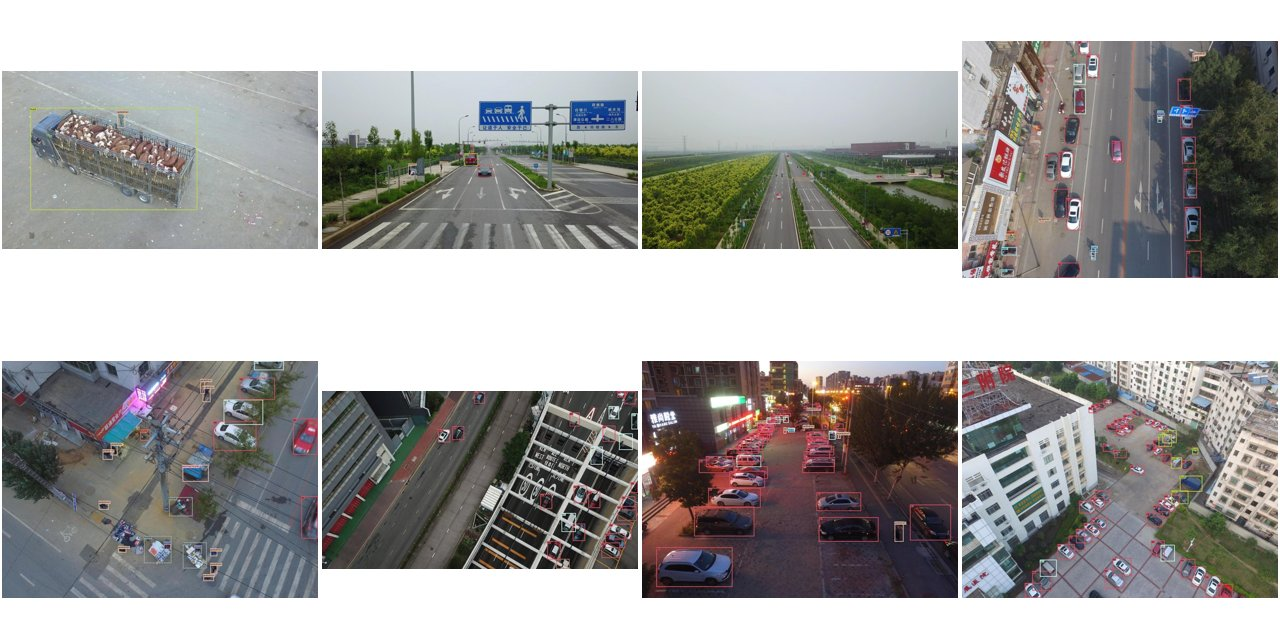

galerie : val


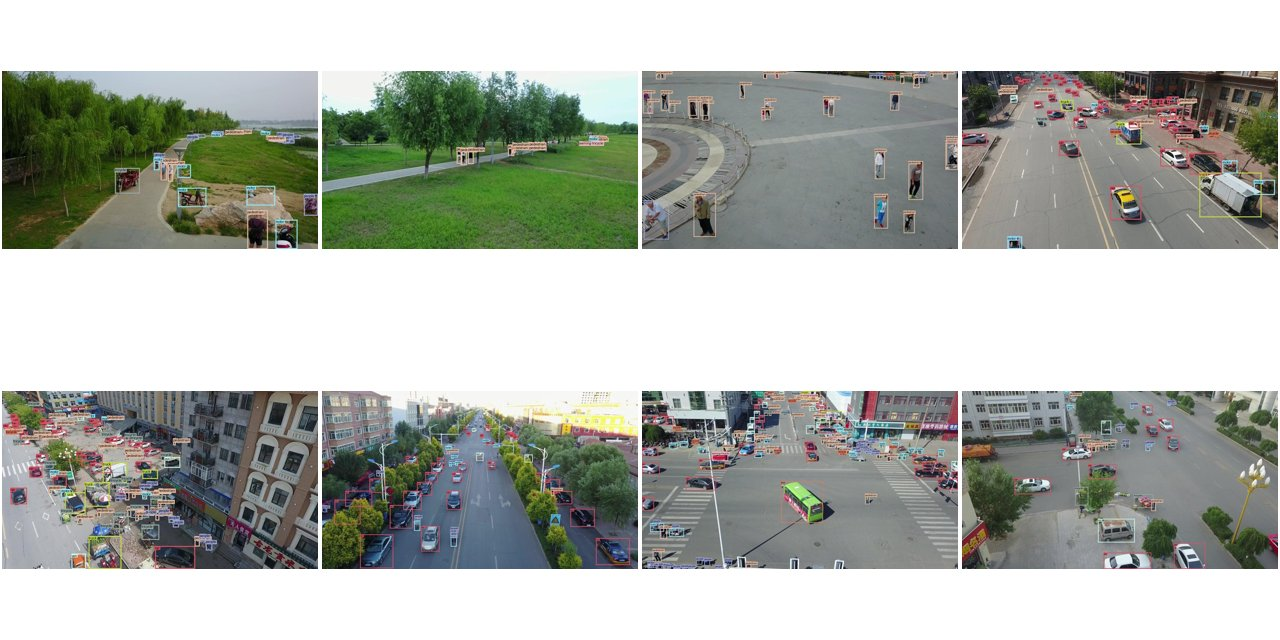

galerie : classes


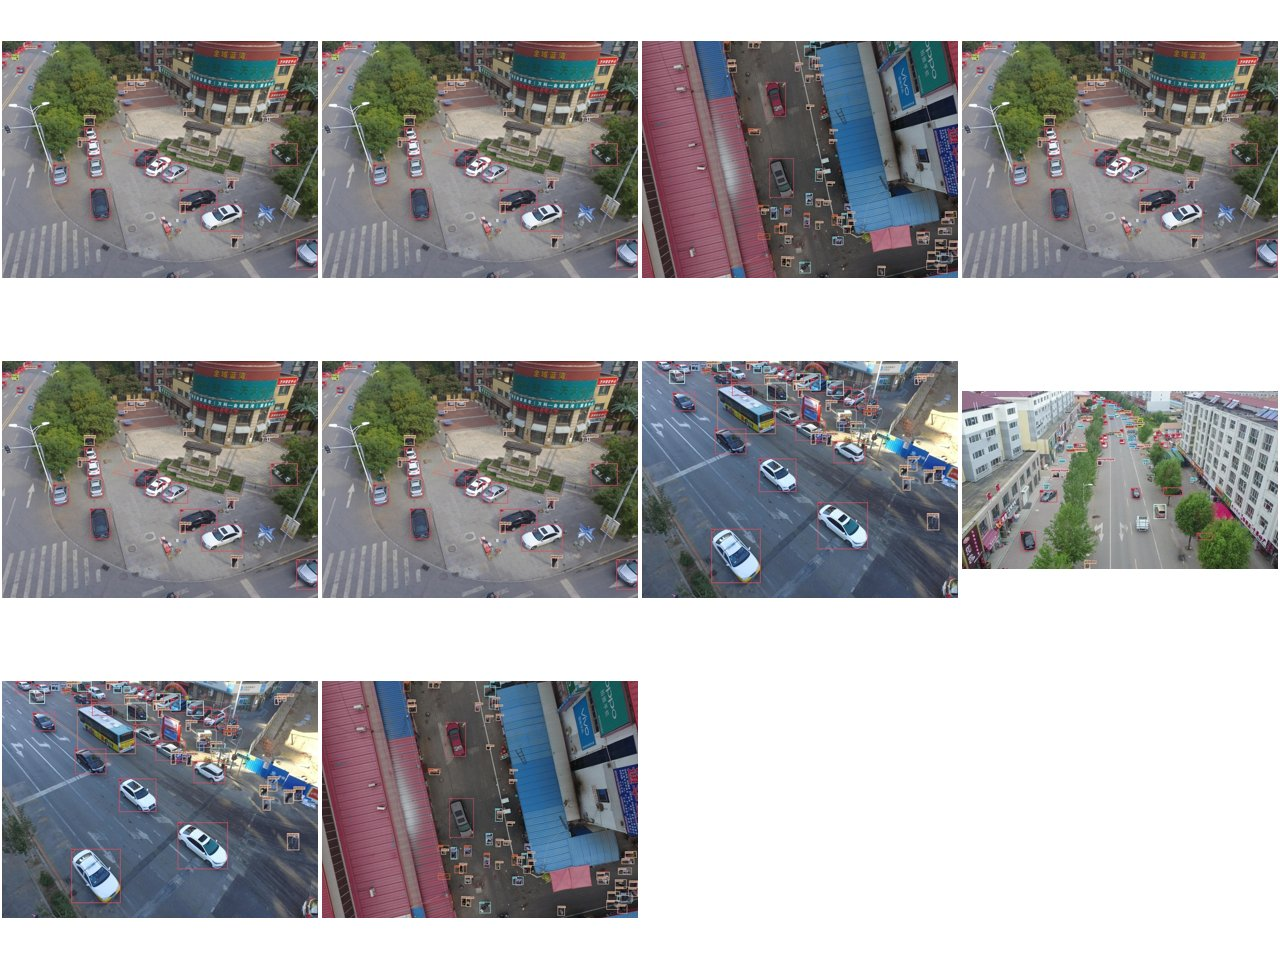

In [4]:
from yolo.data import datasets as D

rows = ["| classe | VOC | COCO |", "|---|---|---|"]
for c in D.DATASETS[DATASET].classes:
    m = [c if DATASET == f else D.MAPPINGS.get((DATASET, f), {}).get(c, "—")
         for f in ("voc", "coco")]
    rows.append(f"| {c} | {m[0]} | {m[1]} |")
display(Markdown("\n".join(rows)))
for g, sheet in STATS.get("galerie", {}).get("planches", {}).items():
    if g != "suspectes":
        print(f"galerie : {g}")
        display(Img(filename=str(Path(OUT, sheet))))

## Comptes et classes (T16.5)

Comptes par split (annotations, split entier), face aux effectifs officiels de la
fiche ; objets par classe et co-occurrence.

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| train | 6 471 | 343 204 | 0 | 0 | 42 / 902 | 96,9 % | 13x13 93,8 % · 26x26 75,1 % | 32,33 % | 21 / 0 |
| val | 548 | 38 759 | 0 | 0 | 65 / 317 | 97,9 % | 13x13 95,2 % · 26x26 77,6 % | 33,04 % | 3 / 0 |
| ensemble | 7 019 | 381 963 | 0 | 0 | 43 / 902 | 97,0 % | 13x13 93,9 % · 26x26 75,3 % | 32,40 % | 24 / 0 |

train : 6471 images, 343204 objets ; officiel 6471 / — : ok
val : 548 images, 38759 objets ; officiel 548 / — : ok


| classe | train : objets (images) | val : objets (images) | côté médian (px, letterbox) | petits |
|---|---|---|---|---|
| pedestrian | 79 337 (5 366) | 8 844 (520) | 5 | 100 % |
| people | 27 059 (3 947) | 5 125 (482) | 5 | 100 % |
| bicycle | 10 480 (2 755) | 1 287 (364) | 6 | 100 % |
| car | 144 866 (6 133) | 14 064 (515) | 9 | 95 % |
| van | 24 956 (4 948) | 1 975 (421) | 10 | 95 % |
| truck | 12 875 (3 551) | 750 (266) | 13 | 89 % |
| tricycle | 4 812 (1 688) | 1 045 (337) | 10 | 98 % |
| awning-tricycle | 3 246 (1 151) | 532 (220) | 10 | 98 % |
| bus | 5 926 (2 023) | 251 (131) | 14 | 87 % |
| motor | 29 647 (4 237) | 4 886 (485) | 6 | 100 % |

Rapport classe la plus / la moins fréquente : 42.

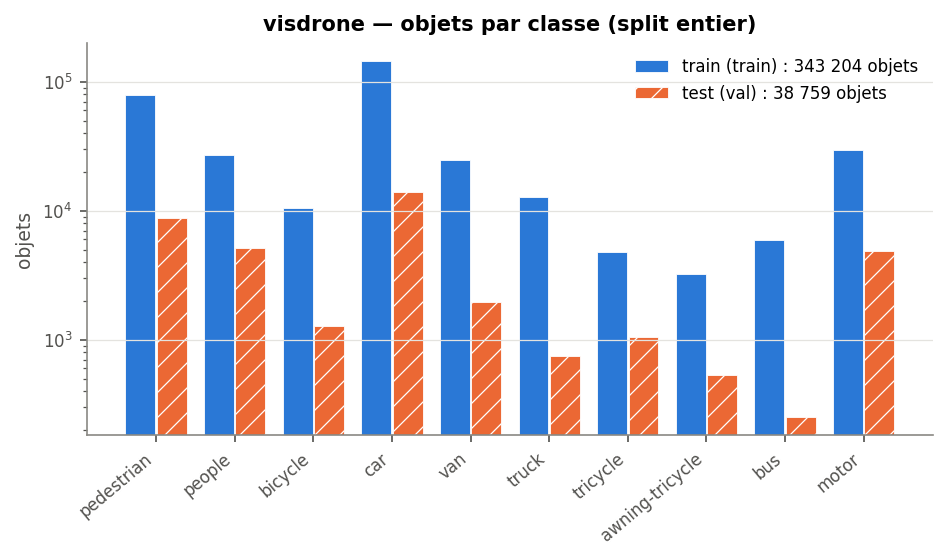

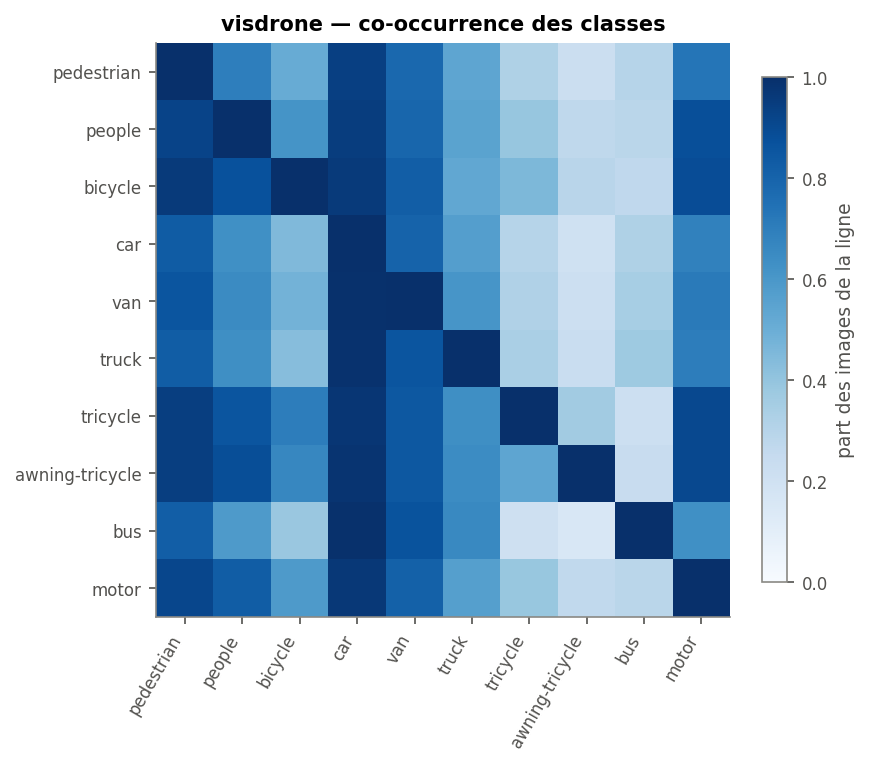

In [5]:
table(DS.md_synthese)
chk = DS.check_official(STATS)
for sp, i, o, (a, b), ok in chk:
    print(f"{sp} : {i} images, {o} objets ; officiel {a or '—'} / {b or '—'} : "
          f"{'ok' if ok else 'écart (voir les notes de la fiche)'}")
table(DS.md_classes)
show("classes")
show("cooccurrence")

## Géométrie des boîtes (T16.6)

Tailles en pixels d'origine et d'entrée (letterbox et stretch à `SIZE`), catégories
COCO avant et après redimensionnement, part des objets plus petits qu'une cellule de
chaque tête, centres des boîtes.

| repère | petits | moyens | grands | côté médian (px) | plus petits qu'une cellule | hauteur < 8 px |
|---|---|---|---|---|---|---|
| image d'origine | 61,3 % | 33,5 % | 5,2 % | 26 | — | — |
| letterbox 416×416 | 97,0 % | 3,0 % | 0,0 % | 7 | 13x13 93,9 % · 26x26 75,3 % | 52,6 % |
| stretch 416×416 | 94,6 % | 5,4 % | 0,1 % | 9 | 13x13 88,8 % · 26x26 61,9 % | 29,1 % |

381 963 objets non-difficult ; pas des têtes : 13x13 → 32 px, 26x26 → 16 px.

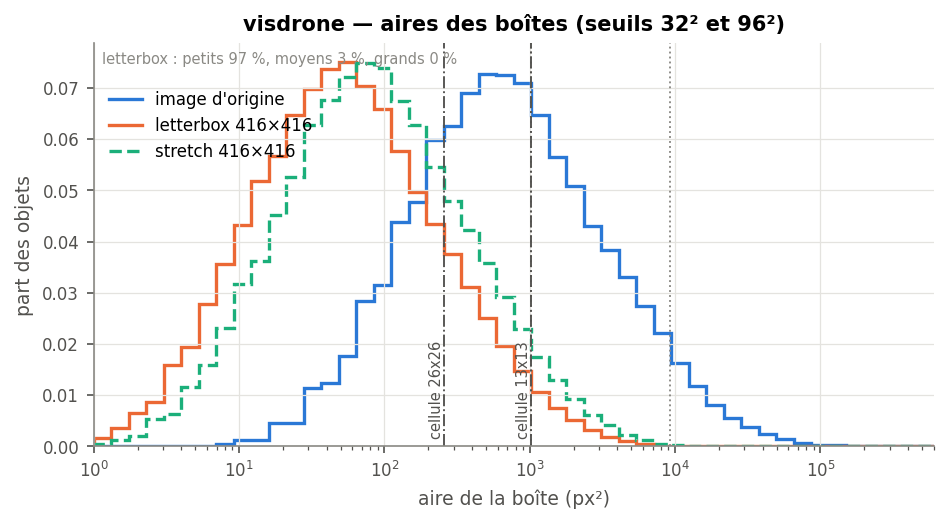

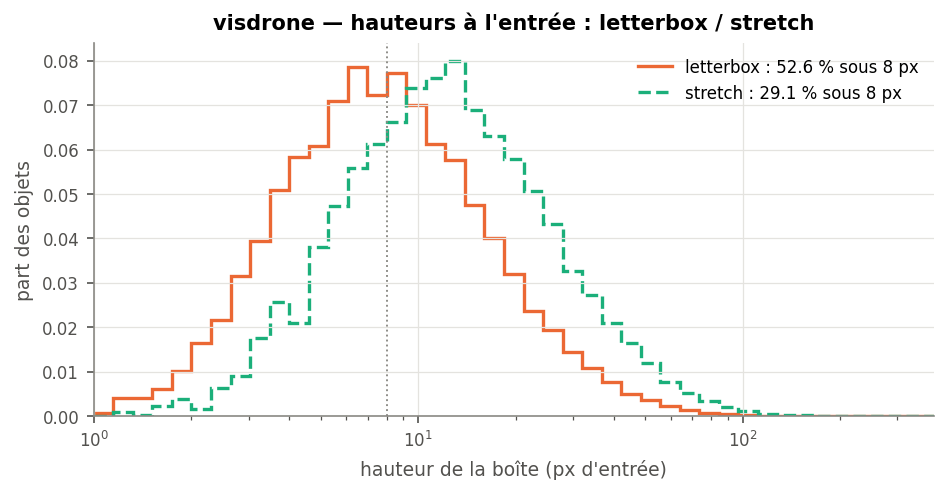

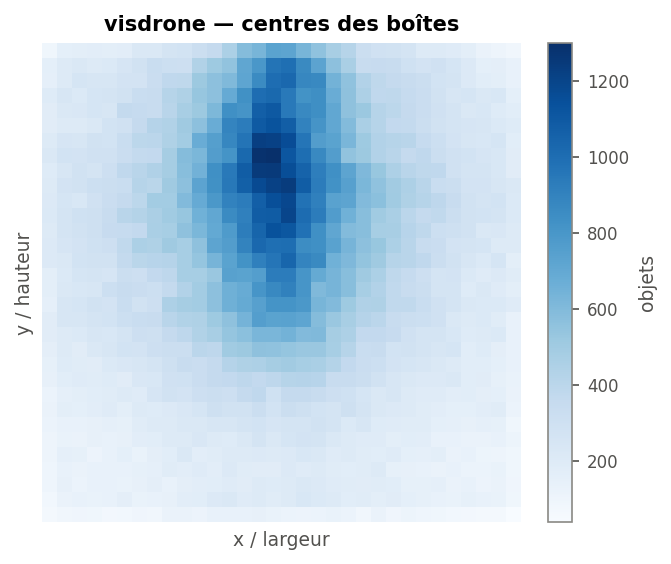

In [6]:
table(DS.md_geometrie)
show("tailles")
show("letterbox_stretch")
show("centres")

## Densité et collisions (T16.7)

Objets par image face aux 256 emplacements de `yolo_post` ; cibles perdues quand deux
objets tombent sur la même cellule et la même ancre (`build_targets`, ancres de `NET`).

| partie | objets/image moy. | méd. | max | > 256 / > 1 024 | cibles perdues | par tête (perdues / objets) | images touchées |
|---|---|---|---|---|---|---|---|
| train | 53,0 | 42 | 902 | 21 / 0 | 110 957 / 343 204 (32,33 %) | 13x13 : 14 182 / 82 115 · 26x26 : 96 775 / 261 089 | 6 007 |
| val | 70,7 | 65 | 317 | 3 / 0 | 12 805 / 38 759 (33,04 %) | 13x13 : 1 566 / 8 457 · 26x26 : 11 239 / 30 302 | 524 |
| ensemble | 54,4 | 43 | 902 | 24 / 0 | 123 762 / 381 963 (32,40 %) | 13x13 : 15 748 / 90 572 · 26x26 : 108 014 / 291 391 | 6 531 |

Ancres de `build/m11/cfg/tiny-yolov3-visdrone.cfg` ; objets non-difficult, comme à l'entraînement.

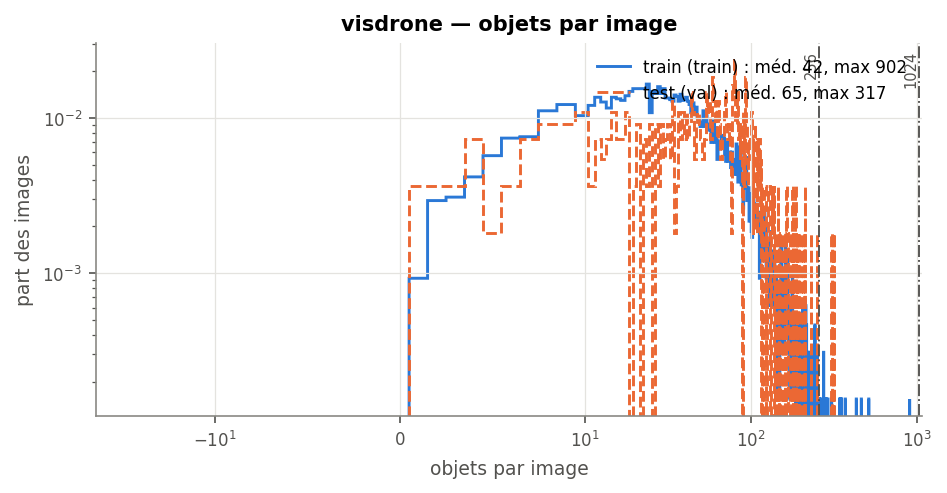

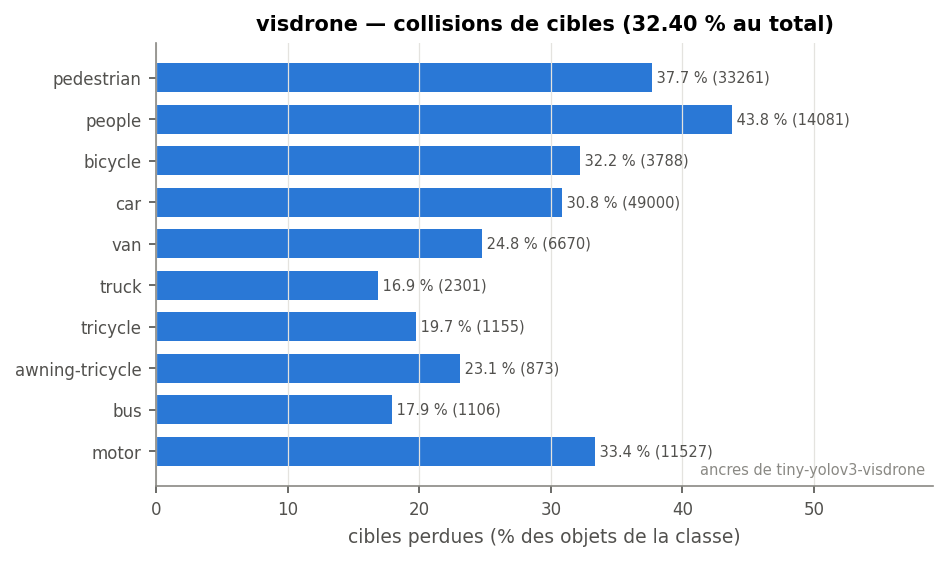

In [7]:
table(DS.md_densite)
show("densite")
show("collisions")

## Images (T16.8)

Résolutions sur le split entier (annotations) ; canaux, intensités et luminance sur
`SAMPLE` images par partie, face à VOC2007 test (échelles INT8 de M4).

| partie | résolutions (3 premières) | distinctes | pixels sur | canaux | moyenne par canal | écart type par canal | luminance moy. | niveaux 8 bits → INT8 |
|---|---|---|---|---|---|---|---|---|
| train | 1400×1050 (2 498), 1400×788 (1 299), 2000×1500 (772) | 11 | 200 images | 3 | 101,4 / 103,8 / 100,3 | 60,4 / 59,6 / 61,0 | 100,8 | 256 → 128 |
| val | 1360×765 (408), 960×540 (121), 1920×1080 (19) | 3 | 200 images | 3 | 114,9 / 120,5 / 116,2 | 54,1 / 52,8 / 55,2 | 117,1 | 256 → 128 |
| ensemble | 1400×1050 (2 498), 1400×788 (1 299), 1360×765 (1 151) | 11 | 200 images | 3 | 95,6 / 97,8 / 94,4 | 61,3 / 61,4 / 63,0 | 97,1 | 256 → 128 |

Référence VOC2007 test (200 images, graine 0) : luminance moyenne 107,7, moyenne par canal 112,1 / 107,1 / 98,5.

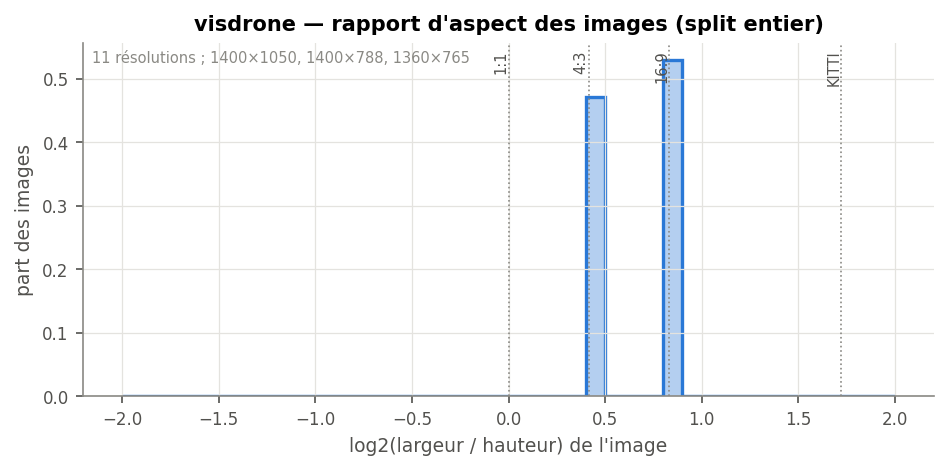

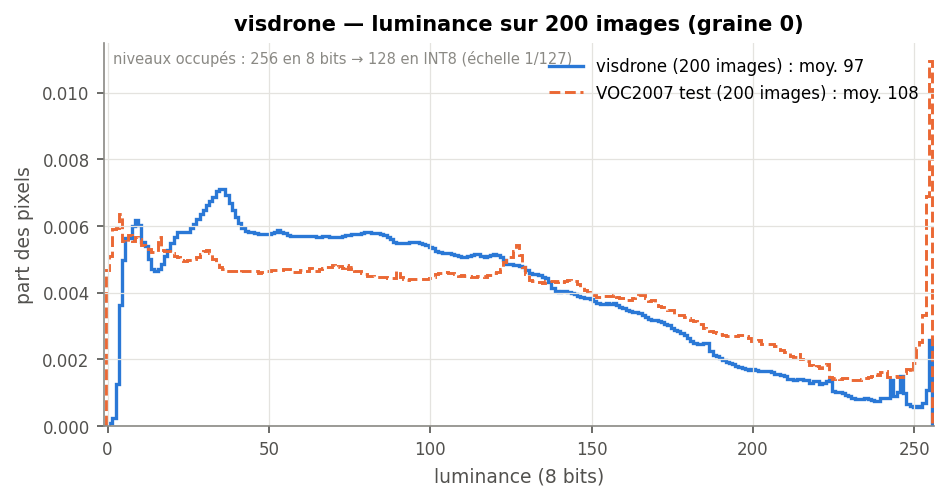

In [8]:
table(DS.md_images)
show("resolutions")
show("intensites")

## Ancres (T16.9)

Boîtes du groupe train en pixels d'entrée letterbox, ancres de la cfg, de VOC, de
COCO et du k-means (`tools/kmeans_anchors.py`, mêmes `--size` et `--seed`).

| ancres | w,h (px à 416×416) | IoU moyenne |
|---|---|---|
| VOC (tiny-yolov2-voc) | `35,38  109,141  212,364  301,164  532,337` | 0,1032 |
| VOC (tiny-yolov3-voc) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,3505 |
| COCO (tiny-yolov3-coco) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,3505 |
| cfg du jeu (tiny-yolov3-visdrone) | `3,4  7,8  16,9  11,17  27,22  50,44` | 0,6010 |
| k-means k = 5 (graine 0) | `3,4  8,9  18,14  28,26  54,46` | 0,5702 |
| k-means k = 6 (graine 0) | `3,4  7,8  16,9  11,17  27,22  50,44` | 0,6026 |

343 204 boîtes non-difficult du groupe train, letterbox 416×416.

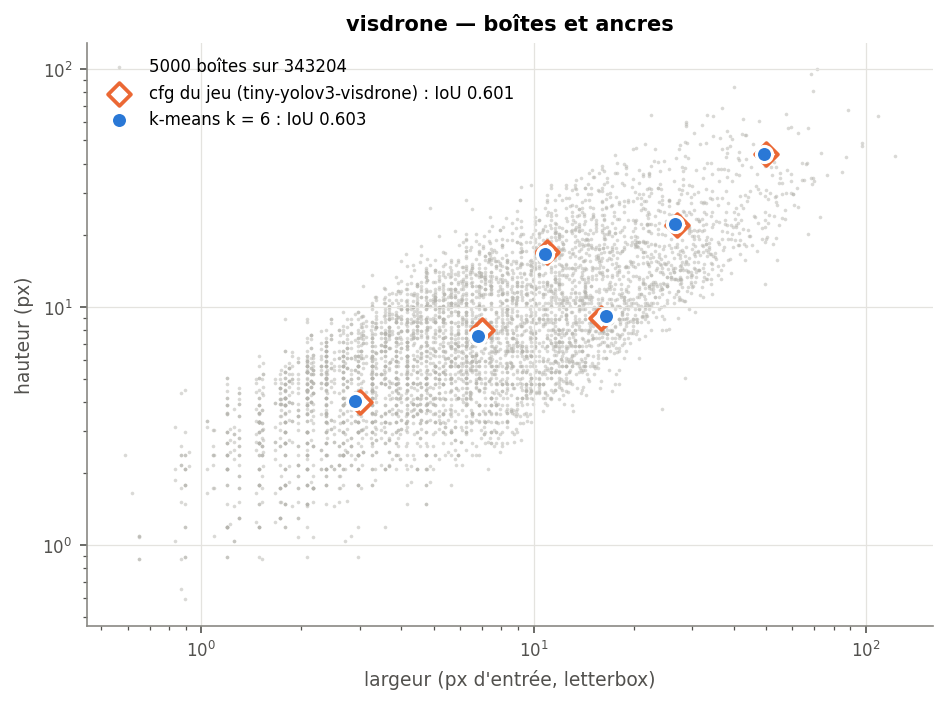

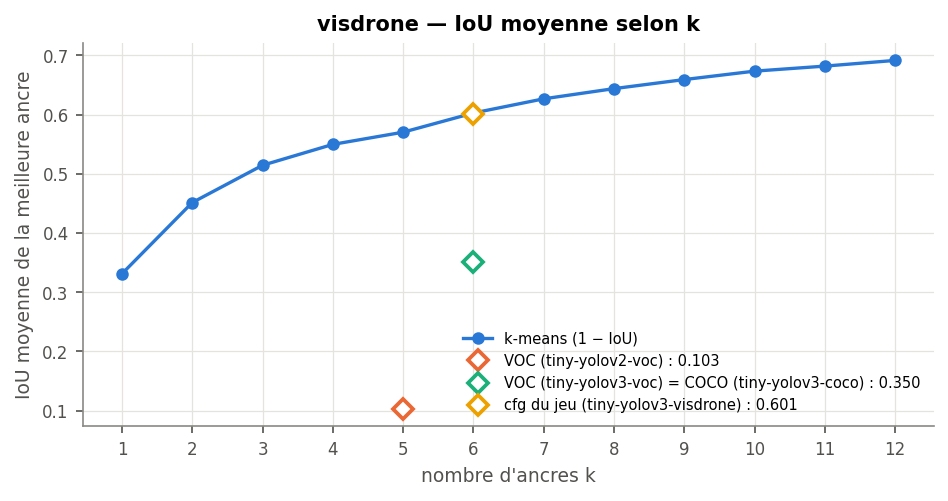

In [9]:
table(DS.md_ancres)
show("ancres")
show("ancres_k")

## Qualité des annotations (T16.10)

Boîtes retirées ou rognées par le chargeur, dégénérées, doublons, régions retirées ;
l'analyse signale, elle ne corrige pas (une correction passe par M11).

| partie | retirées (make_sample) | rognées | côté < 2 px (orig. / entrée) | doublons (IoU > 0,95) | régions retirées par le chargeur |
|---|---|---|---|---|---|
| train | 1 | 0 | 23 / 30 290 | 19 | ignorée (0) 8 813, others (11) 1 532 |
| val | 0 | 0 | 1 / 2 669 | 2 | ignorée (0) 1 378, others (11) 32 |
| ensemble | 1 | 0 | 24 / 32 959 | 21 | ignorée (0) 10 191, others (11) 1 564 |

9999940_00000_d_0000041 : score 3 (retirées 0, rognées 0, dégénérées 3, doublons 0)
0000026_03500_d_0000031 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
0000134_01791_d_0000147 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
0000137_02220_d_0000163 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
0000140_00118_d_0000002 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
0000258_01368_d_0000073 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
0000258_02910_d_0000079 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
0000264_02201_d_0000205 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)
0000277_04201_d_0000559 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
0000338_04313_d_0000160 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)


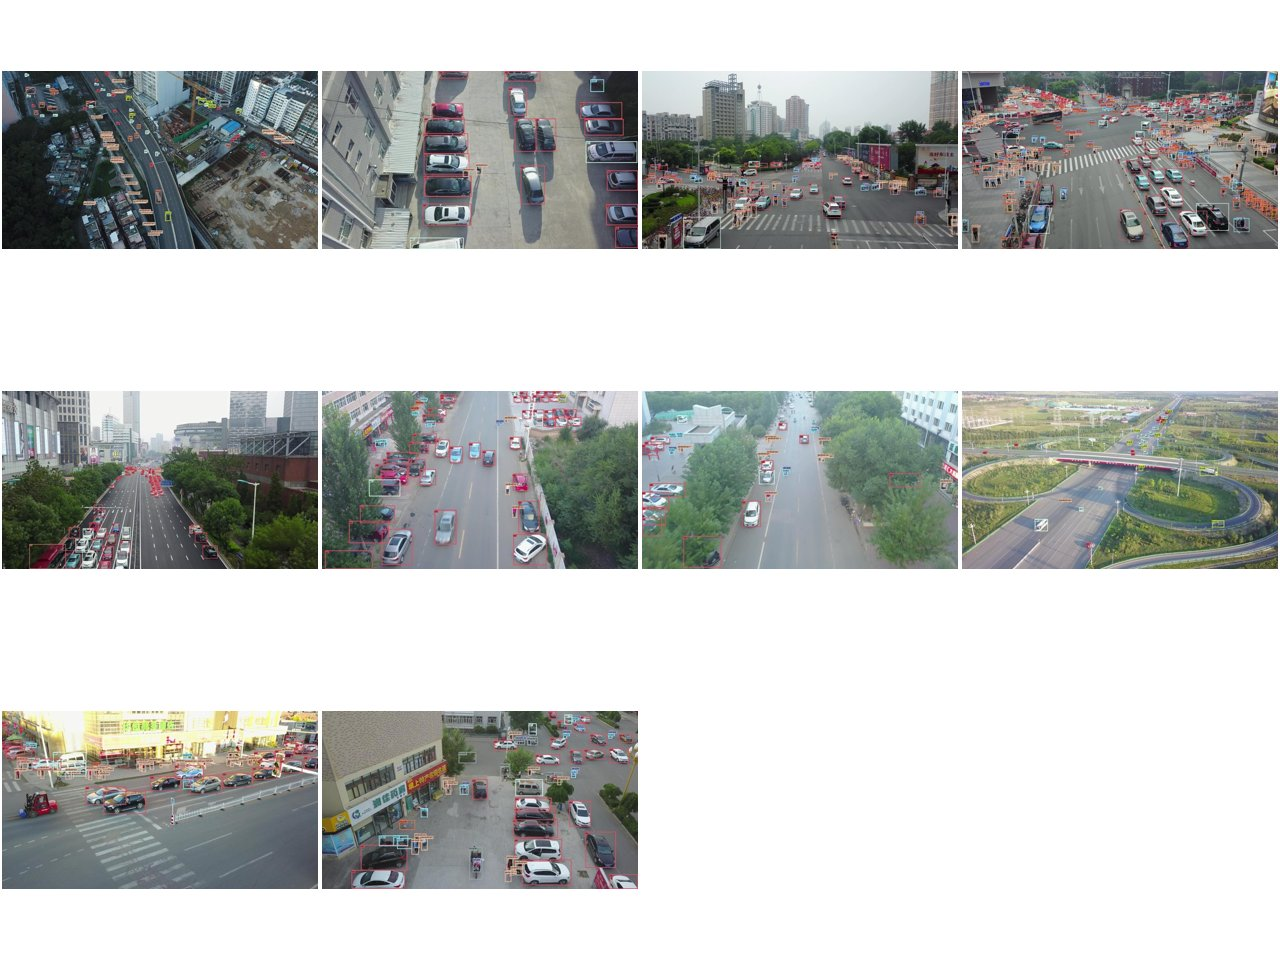

In [10]:
table(DS.md_qualite)
sus = DS.whole(STATS).get("qualite", {}).get("suspects", [])
for d in sus:
    print(f"{d['id']} : score {d['score']} (retirées {d['retirées']}, rognées "
          f"{d['rognées']}, dégénérées {d['dégénérées']}, doublons {d['doublons']})")
sheet = STATS.get("galerie", {}).get("planches", {}).get("suspectes")
if sheet:
    display(Img(filename=str(Path(OUT, sheet))))

## Écart entre splits et couverture hors domaine (T16.11)

Distance en variation totale entre train et test, par grandeur ; part des objets qui
ont une classe VOC ou COCO (ce qu'évaluent les notebooks hors domaine de T14.5).

| grandeur (train ↔ test) | variation totale |
|---|---|
| classes | 0,113 |
| area_in | 0,060 |
| w_in | 0,087 |
| h_in | 0,117 |
| aspect | 0,089 |
| per_image | 0,322 |

| split | classes du modèle | objets couverts | part | évalués (non-difficult) |
|---|---|---|---|---|
| train | VOC | 322 271 | 93,9 % | 322 271 |
| train | COCO | 335 146 | 97,7 % | 335 146 |
| val | VOC | 36 432 | 94,0 % | 36 432 |
| val | COCO | 37 182 | 95,9 % | 37 182 |

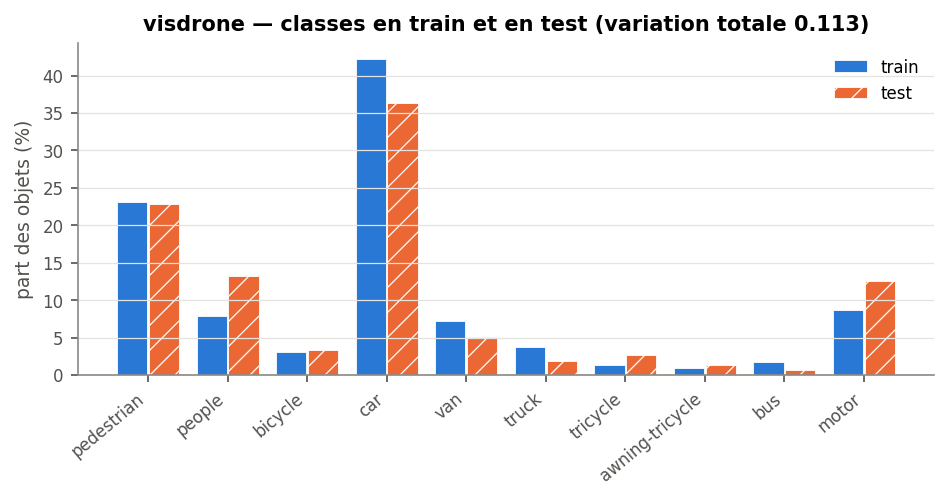

In [11]:
table(DS.md_ecart)
show("ecart")

## Question propre au jeu

Part des objets plus petits qu'une cellule 26×26 ; collisions de cibles. (renvoi : T11.5, T15)

In [12]:
g = DS.whole(STATS)["geometrie"][STATS["params"]["resize"]]
print("plus petits qu'une cellule : " + ", ".join(f"{k} {100 * v:.1f} %"
                                                   for k, v in g["fit_cell"].items()))
display(Markdown(DS.md_par_classe(STATS)))

plus petits qu'une cellule : 13x13 93.9 %, 26x26 75.3 %


| classe | objets (test, non-difficult) | part | côté médian (px) | petits | cibles perdues |
|---|---|---|---|---|---|
| pedestrian | 8 844 | 22,8 % | 5 | 100 % | 39,86 % |
| people | 5 125 | 13,2 % | 5 | 100 % | 43,30 % |
| bicycle | 1 287 | 3,3 % | 7 | 100 % | 32,32 % |
| car | 14 064 | 36,3 % | 10 | 96 % | 28,33 % |
| van | 1 975 | 5,1 % | 11 | 96 % | 27,95 % |
| truck | 750 | 1,9 % | 13 | 88 % | 16,53 % |
| tricycle | 1 045 | 2,7 % | 10 | 99 % | 17,32 % |
| awning-tricycle | 532 | 1,4 % | 9 | 99 % | 24,81 % |
| bus | 251 | 0,6 % | 11 | 89 % | 15,54 % |
| motor | 4 886 | 12,6 % | 6 | 100 % | 33,42 % |

## Résumé

In [13]:
table(DS.md_synthese)
print(f"sorties : {OUT}/ (stats.json, stats.md, figures/, galerie/) ; "
      f"révision {TRACE['rev']}")
print("commandes équivalentes :")
for c in C.HISTORY:
    print("  " + c)

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| train | 6 471 | 343 204 | 0 | 0 | 42 / 902 | 96,9 % | 13x13 93,8 % · 26x26 75,1 % | 32,33 % | 21 / 0 |
| val | 548 | 38 759 | 0 | 0 | 65 / 317 | 97,9 % | 13x13 95,2 % · 26x26 77,6 % | 33,04 % | 3 / 0 |
| ensemble | 7 019 | 381 963 | 0 | 0 | 43 / 902 | 97,0 % | 13x13 93,9 % · 26x26 75,3 % | 32,40 % | 24 / 0 |

sorties : build/notebooks/visdrone/stats/ (stats.json, stats.md, figures/, galerie/) ; révision 214f269
commandes équivalentes :
  python tools/data_stats.py --dataset visdrone --size 416 --resize letterbox --net build/m11/cfg/tiny-yolov3-visdrone.cfg --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/visdrone/stats
